# Regression example

This notebook demonstrates how to perform temporal regression with a Spiking Neural Network (SNN) using EventPropJAX.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from eventax.evnn import EvNN, FFEvNN
from eventax.neuron_models import QIF
from matplotlib import pyplot as plt
import equinox as eqx
import optax
from tqdm import tqdm

%matplotlib inline
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 120

jax.config.update("jax_platform_name", "cpu")

We will use MSE loss:

In [2]:

def loss_fn(model, in_times, target_times):
    first_spikes = jax.vmap(model.ttfs)(in_times)
    target_times = target_times[:, None]
    return jnp.mean((jnp.minimum(first_spikes, 80)/80 - target_times/80) ** 2)

v_and_grad = eqx.filter_value_and_grad(loss_fn)



## Building the SNN

Below we construct a small event-driven SNN (`EvNN`) with a single hidden layer of 20 fully connected neurons (no self-connections) and one output neuron, using Quadratic Integrate and Fire (`QIF`) neurons.
Important hyperparameters:

- `max_solver_time`: max simulated time window (ms or arbitrary units).
- `solver_stepsize`: integration step for the event-driven solver.
- `output_no_spike_value`: fallback value if no spike occurs by `max_solver_time`.
- `tsyn`, `tmem`: synaptic and membrane time constants.
- `blim`, `wlim`: parameter initialization bounds for biases and weights, respectively.
- `max_event_steps`: maximum amount of overall spikes occurring until first output spike occurred for every output neuron.
- `buffer_capacity`: internal spike buffer capacity (buffer for handling delays).


In [3]:
n_pop = 20
n_neurons = n_pop + 1  # 20 population + 1 output
in_size = 1

# Build wmask: shape (n_neurons + in_size, n_neurons) = (12, 11)
wmask = jnp.zeros((n_neurons + in_size, n_neurons), dtype=jnp.float32)

# Population fully connected
wmask = wmask.at[:n_pop, :n_pop].set(1)

# Remove self-connections
wmask = wmask.at[jnp.arange(n_pop), jnp.arange(n_pop)].set(0)

# Population -> output neuron
wmask = wmask.at[:n_pop, n_pop].set(1)

# Input -> population
wmask = wmask.at[n_neurons:, :n_pop].set(1)

output_neurons = jnp.zeros((n_neurons,), dtype=bool)
output_neurons = output_neurons.at[n_pop].set(True)

input_neurons = jnp.zeros((n_neurons,), dtype=bool)
input_neurons = input_neurons.at[:n_pop].set(True)

key = jax.random.PRNGKey(0)
snn = EvNN(
    neuron_model=QIF,
    n_neurons=n_neurons,
    in_size=in_size,
    max_solver_time=80.0,
    key=key,
    wmask=wmask,
    output_neurons=output_neurons,
    input_neurons=input_neurons,
    solver_stepsize=0.1,
    dtype=jnp.float32,
    tsyn=5.0,
    tmem=20.0,
    blim=0.5,
    wlim=40.0,
    wmean=20.0,
    max_event_steps=500,
)


## Create Data

We’ll sample `n_samples` input times $x$ uniformly from $[0, 30]$ and define targets

$$ y = A\cdot\sin(2\pi x / 10) + x + c. $$

Here $x$ represents the input time, while $y$ is the targeted output time. We add $x + c$ to maintain causality and account for the forward pass duration of the SNN, where $c$ is a constant offset. $A$ changes the shape of the curve.

We will always input a spike at $t=0$ and another spike at the wanted input time $x$.


In [4]:
# Data hyperparameters
bs = 64
n_samples = 100_000

amplitude = 5.0
offset = 30.0

# Training data
X = jax.random.uniform(key, shape=(n_samples,)) * 30.0
y = amplitude * jnp.sin(2 * jnp.pi * X / 10) + X + offset

# Test data
X_test = jnp.linspace(0.0, 30.0, 100)
y_test = amplitude * jnp.sin(2 * jnp.pi * X_test / 10) + X_test + offset

def to_event_batch(x_scalar_batch):
    zeros = jnp.zeros_like(x_scalar_batch)
    times = jnp.stack([zeros, x_scalar_batch], axis=-1)
    return times[:, None, :]



## Training Step (Optax + Equinox JIT)

We JIT‑compile a single training update (`train_step`) and a batched forward function for evaluation.


In [5]:

optimizer = optax.adam(0.1)
optim_state = optimizer.init(snn)

@eqx.filter_jit
def train_step(model, opt_state, in_times, target_times):
    loss, grad = v_and_grad(model, in_times, target_times)
    updates, opt_state = optimizer.update(grad, opt_state, params=eqx.filter(model, eqx.is_array))
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

@eqx.filter_jit
def batched_ttfs(model, in_times):
    return jax.vmap(model.ttfs)(in_times).squeeze(-1)



## Train and Visualize

We iterate over the dataset in mini-batches. Every 100 steps, we compute predictions on a small test grid and plot
the **true target curve** against the **model’s predicted TTFS**.


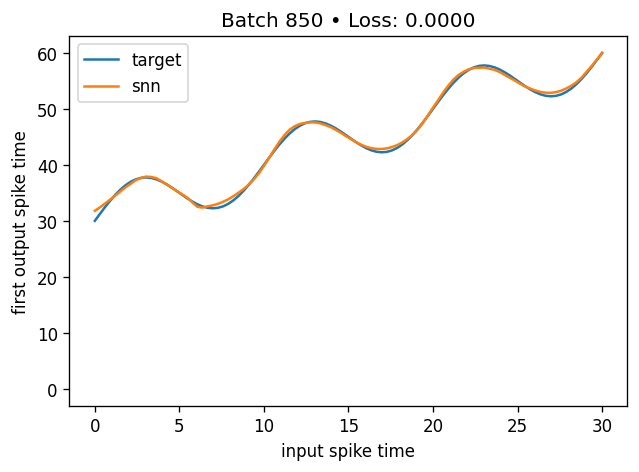

 55%|███████████████████████████████████████████████████████████████████████████████                                                                 | 858/1562 [03:47<03:24,  3.44it/s]

In [ ]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np

num_steps = n_samples // bs
print(f"Training for {num_steps} steps...")

W_hist, IC_hist, steps_hist = [], [], []

mask_bool = np.array(snn.get_wmask(), dtype=bool)

def snapshot(step_idx: int):
    W = np.array(snn.neuron_model.weights)
    IC = np.array(snn.neuron_model.ic)
    W_hist.append(W[mask_bool])
    IC_hist.append(IC)
    steps_hist.append(step_idx)

fig, ax = plt.subplots()
(line_target,) = ax.plot(X_test, y_test, label="target")
(line_pred,) = ax.plot(X_test, y_test * 0, label="snn")  # placeholder
ax.set_xlabel("input spike time")
ax.set_ylabel("first output spike time")
ax.legend()

snapshot(step_idx=0)

for i in tqdm(range(num_steps)):
    start = i * bs
    stop = start + bs
    x_batch = X[start:stop]
    y_batch = y[start:stop]

    Xb = to_event_batch(x_batch)
    snn, optim_state, loss = train_step(snn, optim_state, Xb, y_batch)

    if i % 10 == 0:
        X_test_in = to_event_batch(X_test)
        y_pred = batched_ttfs(snn, X_test_in)

        line_pred.set_ydata(y_pred)
        ax.set_title(f"Batch {i} • Loss: {float(loss):.4f}")

        clear_output(wait=True)
        display(fig)
        plt.pause(0.001)

        snapshot(step_idx=i)

snapshot(step_idx=num_steps)

W_hist = np.stack(W_hist)
IC_hist = np.stack(IC_hist)
steps_hist = np.asarray(steps_hist)

def plot_all_curves(A: np.ndarray, steps: np.ndarray, title: str, ylabel: str):
    if A.size == 0 or A.shape[1] == 0:
        print(f"{title}: no data to plot.")
        return
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(steps, A, linewidth=0.8)
    ax.set_xlabel("training step")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.show()

plot_all_curves(W_hist, steps_hist, "Weights over time (all synapses)", "weight")
plot_all_curves(IC_hist, steps_hist, "Bias currents over time (all neurons)", "bias current")